# Euclid Q1-like mock images of TNG50 galaxies

This notebook walks through the pipeline in `euclid_mocks` and runs one example end to end.

| Stage | Module | What happens |
|---|---|---|
| 1. Source | `tng_api`, `source` | Render size = 22.5 stellar half-mass radii → arcmin at the snapshot redshift. Selection cuts. `sphMap` render per band (mag/arcsec²) → Jy/pixel |
| 2. Dither | `resample` | Drizzle the true sky onto the VIS (0.1″) or NISP (0.3″) detector at the 4 Q1 dither positions (sub-pixel phases) |
| 3. Detector | `detector`, `bands` | **VIS**: 4 × 566 s + 2 × 95 s exposures, Jy → e⁻ → Poisson → ADU/s. **NISP**: MACC(4,16,4) up-the-ramp with Poisson + read noise and the group-difference estimator |
| 4. Stack | `bands` | Drizzle all exposures onto one grid and median-combine. VIS defines the reference grid, and every NISP band is drizzled straight onto it |
| 5. Background + PSF | `background` | One empty sky patch per galaxy (from the empty-region catalogue). Per band: δ→Euclid PSF matching kernel, convolve, rescale to the mosaic zeropoint, add the background |
| 6. Output | `science_ready` | `[VIS, NIR-Y, NIR-J, NIR-H]` in Jy plus `*DET` significance maps. A hard check ensures all 8 extensions share one shape and WCS |

Part A runs offline on the **mock MER tile** with a **synthetic source**, so it needs no credentials.
Part B uses a real TNG50 subhalo, and Part C runs a small batch over two snapshots and plots the results.
Parts B and C need `config/tng_credentials.yaml`. Part D builds background-position catalogues from MER tiles.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import fitsbolt
from astropy.io import fits
from astropy.visualization import ImageNormalize, ZScaleInterval

from euclid_mocks.config import config_from_dict, configure_logging, load_config
from euclid_mocks.constants import ALL_BANDS
from euclid_mocks.mock_tile import build_mock_tile, synthetic_renders
from euclid_mocks.pipeline import galaxy_rng, make_mock, make_mock_from_renders, mock_header_cards, run_snapshot

cfg = load_config()
configure_logging(cfg)
print("MER input :", cfg.paths.euclid_mer_dir)
print("output    :", cfg.paths.output_dir)

MER input : /Users/lruhberg/Documents/Projects/Cosmic-Cuddles-Euclid-Mocks/data/mock_tile/MER
output    : /Users/lruhberg/Documents/Projects/Cosmic-Cuddles-Euclid-Mocks/output


## Euclid inputs: the mock MER tile

`build_mock_tile` writes a 1024² px tile in the Q1 MER layout: background-subtracted mosaics and PSF grids for all
four bands, a segmentation map, and an empty-region catalogue. The catalogue is built from the segmap with the same
algorithm that produced the real Q1 `EmptyRegionsCatalog`. For production, point `paths.euclid_mer_dir` and
`paths.empty_region_dir` at the real data.

,Unnamed: 0,Folder_name,pos_x,pos_y,pos_ra,pos_dec,min_object_distance,border_distance
0,0,999000001,684.000000,130.000000,269.988224,65.989402,31,130
1,1,999000001,739.000000,109.000000,269.984470,65.988819,73,109
2,2,999000001,820.000000,119.000000,269.978940,65.989096,20,119
3,3,999000001,917.000000,100.000000,269.972319,65.988567,91,100
4,4,999000001,220.785268,124.706617,270.019846,65.989254,45,124


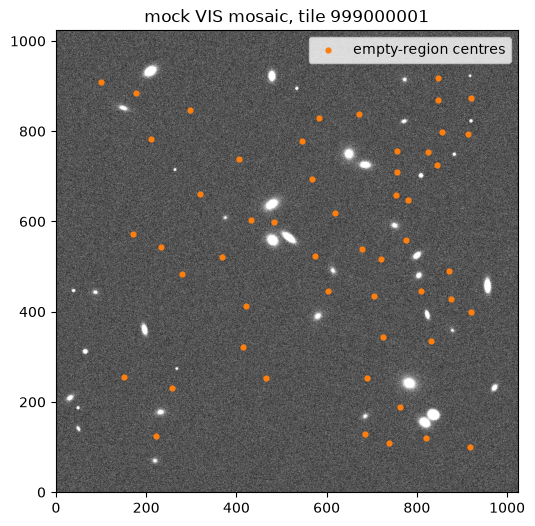

In [2]:
from pathlib import Path
def normalised(path, extension):
    """Read one FITS extension with fitsbolt and asinh-normalise it to a 2D uint8 image."""
    # fitsbolt expects string paths, not pathlib.Path
    (image,) = fitsbolt.load_and_process_images(
        [str(path)], fits_extension=extension, n_output_channels=1, size=None,
        normalisation_method=fitsbolt.NormalisationMethod.ASINH, show_progress=False,
    )
    return image[..., 0]


def rgb_composite(path):
    """Return an asinh-normalised RGB image (R=NIR-H, G=NIR-Y, B=VIS) of a ScienceReady file."""
    (image,) = fitsbolt.load_and_process_images(
        [str(path)], fits_extension=["NIR-H", "NIR-Y", "VIS"], n_output_channels=3, size=None,
        normalisation_method=fitsbolt.NormalisationMethod.ASINH, show_progress=False,
    )
    return image


def show_science_ready(path):
    """Plot the RGB composite plus the four science and four DET extensions of a ScienceReady file."""
    fig, axes = plt.subplots(2, 5, figsize=(17, 7))
    axes[0, 0].imshow(rgb_composite(path), origin="lower")
    axes[0, 0].set_title("RGB (H, Y, VIS)")
    for col, band in enumerate(ALL_BANDS, start=1):
        for row, ext in enumerate([band.value, f"{band.value}DET"]):
            image = normalised(path, ext)
            axes[row, col].imshow(image, origin="lower", cmap="magma")
            axes[row, col].set_title(f"{ext}  {image.shape}")
    for ax in axes.ravel():
        ax.axis("off")
    fig.tight_layout()
    with fits.open(path) as hdul:
        print({h.name: (h.data.shape, h.header["CRPIX1"]) for h in hdul[1:]})


if not Path(cfg.paths.empty_region_dir).exists():
    build_mock_tile(cfg)

tile = cfg.mock_tile.tile_id
mosaic = fits.getdata(f"{cfg.paths.euclid_mer_dir}/{tile}/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE{tile}-MOCK.fits")
regions = pd.read_csv(f"{cfg.paths.empty_region_dir}/TILE_{tile}_empty_regions.csv")

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(mosaic, origin="lower", cmap="gray", norm=ImageNormalize(mosaic, interval=ZScaleInterval()))
ax.scatter(regions.pos_x, regions.pos_y, s=12, c="tab:orange", label="empty-region centres")
ax.set_title(f"mock VIS mosaic, tile {tile}")
ax.legend(loc="upper right")
regions.head()

## Part A: offline example with a synthetic source

`synthetic_renders` returns noise-free mag/arcsec² grids of an interacting disc and companion, in the same format the TNG
API returns. `make_mock_from_renders` runs stages 1b–6 on them.

In [3]:
size_arcmin = 0.15
renders = synthetic_renders(cfg.render.n_pixels, size_arcmin)
sample = {"merger_type": "synthetic", "time_since_last_major": None, "time_since_last_minor": None,
          "time_until_next_major": None, "time_until_next_minor": None}
cards = mock_header_cards(cfg, sample, snapshot=99, size_arcmin=size_arcmin, sub=None, render_method="synthetic")

path, detection_levels = make_mock_from_renders(
    cfg, renders, size_arcmin, sub_id=0, snapshot=99, header_cards=cards, rng=galaxy_rng(cfg.sampling.seed, 99, 0)
)
print(path.name)
print("detection levels [VIS, Y, J, H]:", np.round(detection_levels, 1))

synthetic_sub-0_snap-99_view-1,2_BKGPSF_999000001_17.fits
detection levels [VIS, Y, J, H]: [117.   28.6  34.8  37.8]


{'VIS': ((62, 62), 31.5), 'NIR-Y': ((62, 62), 31.5), 'NIR-J': ((62, 62), 31.5), 'NIR-H': ((62, 62), 31.5), 'VISDET': ((62, 62), 31.5), 'NIR-YDET': ((62, 62), 31.5), 'NIR-JDET': ((62, 62), 31.5), 'NIR-HDET': ((62, 62), 31.5)}


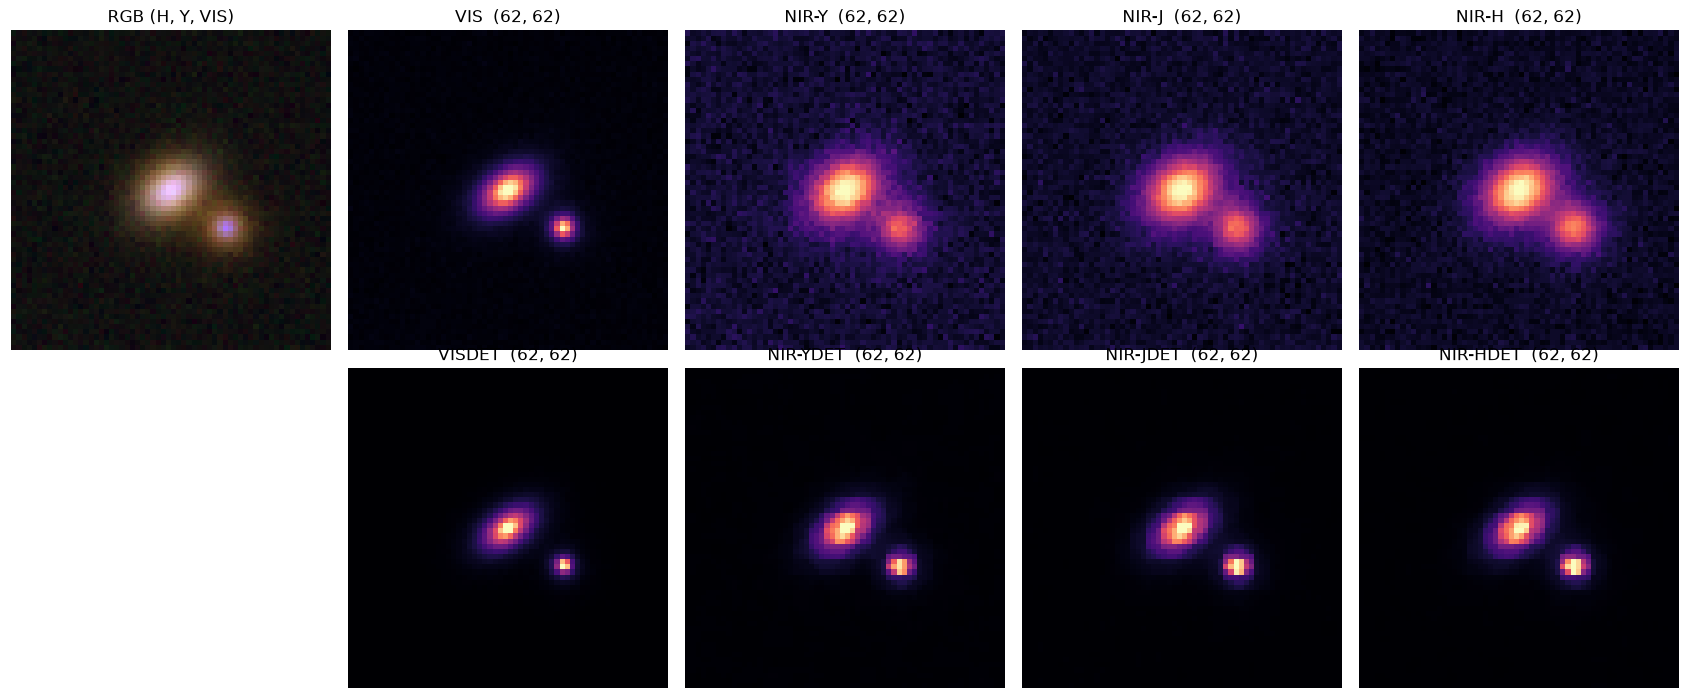

In [4]:
show_science_ready(path)

Every extension reports the same shape and reference pixel. `science_ready.assert_same_geometry` enforces this
before any file is written. All plots read and normalise the FITS files with
[fitsbolt](https://pypi.org/project/fitsbolt/) (asinh stretch).

## Part B: a real TNG50 subhalo

This part needs `config/tng_credentials.yaml` (copy it from `config/tng_credentials.example.yaml`). It picks the
first subhalo with $10^{9} < M_\star/M_\odot < 10^{10.3}$ at snapshot 70 (z ≈ 0.44) and runs the full `make_mock`,
which covers metadata, selection cuts, render download, the instrument chain and the background.

> **Render timeout fallback.** `render.method: sphMap` renders every particle of the parent FoF group, so
> companions stay visible. For galaxies in very massive groups this exceeds the render server's gateway limit
> (HTTP 504). The subhalo picked here (ID 17) is a satellite of the most massive TNG50 cluster and is such a case.
> With `render.timeout_fallback.enabled: true` (default), the galaxy is re-rendered in **all** bands with
> `sphMap_subhalo` (its own particles only, so companions that are separate subhaloes are missing). The method used
> is flagged in the CSV column `render_method` and the header card `M_METH`. Set `enabled: false` to record such
> galaxies as `failed` instead.

In [5]:
RUN_TNG_EXAMPLE = Path(cfg.paths.credentials_file).exists()
print("TNG example enabled:", RUN_TNG_EXAMPLE)

TNG example enabled: True


2026-10-07 13:54:57.499 | INFO     | euclid_mocks.pipeline:make_mock:265 - sub 157 snap 95: using existing example_sub-157_snap-95_view-1,2_BKGPSF_999000001_13.fits


subid                                                                  157
snapshot                                                                95
merger_type                                                        example
galaxy_mass                                                       0.743242
stellar_mass                                                      0.108958
max_dm_mass_past                                                 10.881631
max_stellar_mass_past                                             9.276049
time_to_last_major                                                    None
time_to_last_minor                                                    None
time_to_next_major                                                    None
time_to_next_minor                                                    None
hdu_path                 /Users/lruhberg/Documents/Projects/Cosmic-Cudd...
snr                      [66.02028667833551,23.41346534985063,26.935472...
render_method            

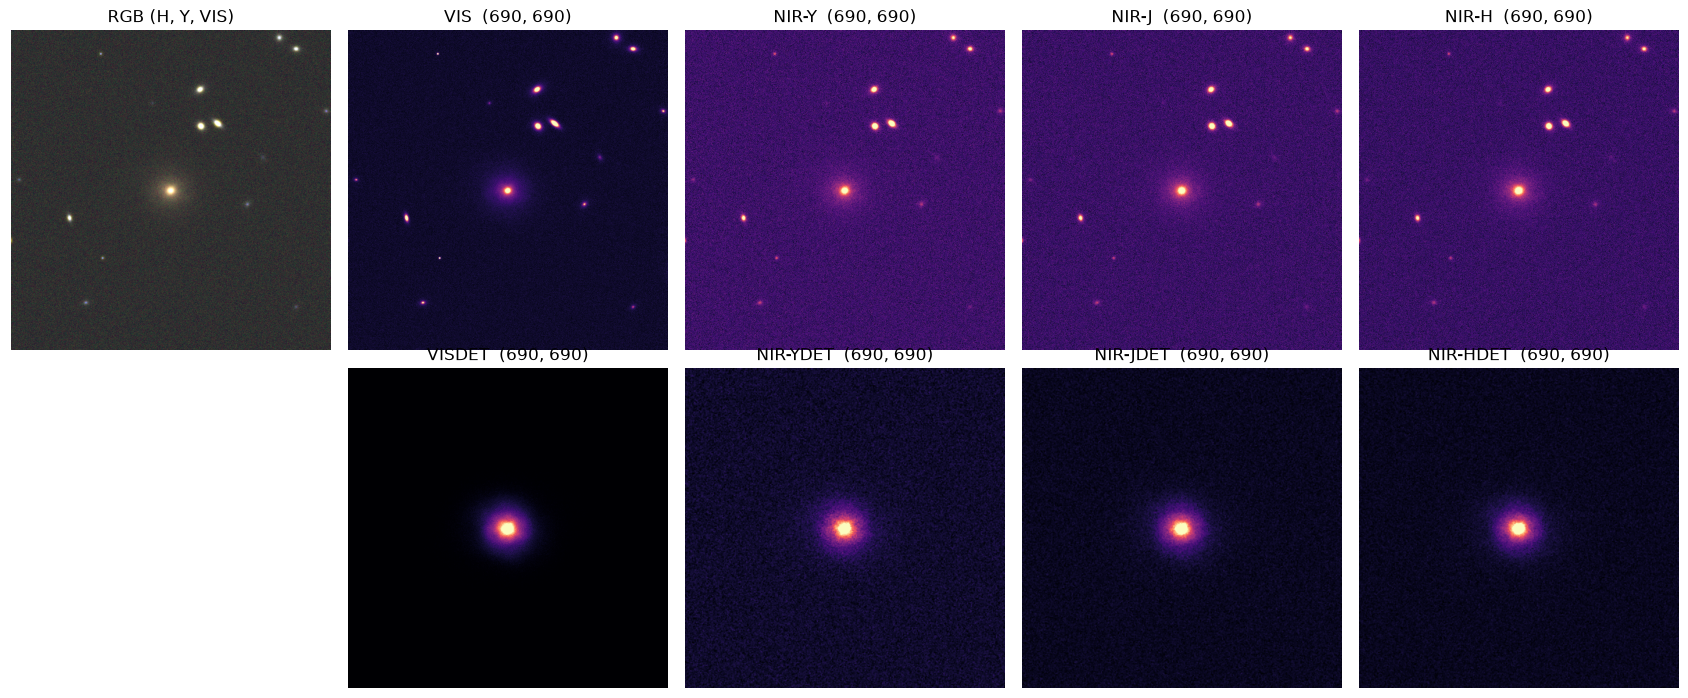

In [ ]:
if RUN_TNG_EXAMPLE:
    from euclid_mocks import tng_api
    from euclid_mocks.constants import TNG_H

    snapshot = 95
    # first galaxy with 10^9 < M*/Msun < 10^10.3; bounds converted to the API's 1e10 Msun/h units
    query = {"limit": 100, "mass_stars__gt": 1e9 / 1e10 * TNG_H, "mass_stars__lt": 10**10.3 / 1e10 * TNG_H}
    sub_id = tng_api.query_subhalos(cfg, snapshot, query)["results"][90]["id"]
    tng_sample = {"subhalo_id": sub_id, "merger_type": "example", "time_since_last_major": None,
                  "time_since_last_minor": None, "time_until_next_major": None, "time_until_next_minor": None}
    row = make_mock(cfg, tng_sample, snapshot, galaxy_rng(cfg.sampling.seed, snapshot, sub_id))
    print(pd.Series(row))
    print("render method:", row["render_method"])
    show_science_ready(row["hdu_path"])

## Part C: several snapshots and samples, then plotting

`run_snapshot` is what `scripts/run_mock_imaging.py` runs for each snapshot. It builds the merger catalogue
(downloading the Eisert et al. 2023 merger history and querying all subhaloes above the mass limit, both cached under
`output/mergers/`), samples galaxies, creates their mocks in a process pool, and writes one summary CSV per snapshot
with `status` ∈ {created, existing, rejected, failed} and `render_method`.

Here the run is limited to **two snapshots with two haloes each** (one major and one minor merger). The first run
of a snapshot takes a while because the merger history files are large.

In [7]:
RUN_TNG_EXAMPLE = Path(cfg.paths.credentials_file).exists()
print("TNG example enabled:", RUN_TNG_EXAMPLE)

batch_cfg = config_from_dict(cfg.toDict())
batch_cfg.sampling.n_major = 1
batch_cfg.sampling.n_minor = 1
batch_cfg.sampling.n_non_merging = 0
batch_cfg.run.n_processes = 2
BATCH_SNAPSHOTS = [59, 53]

if RUN_TNG_EXAMPLE:
    csv_paths = [run_snapshot(batch_cfg, snapshot) for snapshot in BATCH_SNAPSHOTS]
    batch = pd.concat([pd.read_csv(p) for p in csv_paths], ignore_index=True)
    display(batch[["snapshot", "subid", "merger_type", "status", "render_method", "snr", "error"]])

2026-10-07 13:54:58.047 | INFO     | euclid_mocks.pipeline:run_snapshot:346 - snap 59: processing 2 galaxies


TNG example enabled: True


2026-10-07 13:55:05.449 | INFO     | euclid_mocks.pipeline:make_mock:265 - sub 511897 snap 59: using existing major_sub-511897_snap-59_view-1,2_BKGPSF_999000001_33.fits
2026-10-07 13:55:05.546 | INFO     | euclid_mocks.pipeline:make_mock:265 - sub 382940 snap 59: using existing minor_sub-382940_snap-59_view-1,2_BKGPSF_999000001_31.fits
2026-10-07 13:55:05.584 | INFO     | euclid_mocks.pipeline:run_snapshot:357 - snap 59: wrote /Users/lruhberg/Documents/Projects/Cosmic-Cuddles-Euclid-Mocks/output/V_2_1_TIMESCALE_part_1perc_recombined_df_snap59_seed42.csv
2026-10-07 13:55:05.588 | INFO     | euclid_mocks.pipeline:run_snapshot:346 - snap 53: processing 2 galaxies
2026-10-07 13:56:24.598 | WARNING  | euclid_mocks.tng_api:_request:92 - TNG request failed (HTTP 504 Gateway Time-out) for https://www.tng-project.org/api/TNG50-1/snapshots/53/subhalos/62395/vis.hdf5
2026-10-07 13:56:24.598 | WARNING  | euclid_mocks.pipeline:fetch_renders:220 - sphMap NIR-Y render of sub 62395 (snap 53) timed out

,snapshot,subid,merger_type,status,render_method,snr,error
0,59,511897,major,existing,sphMap,"[4.898577858702172,1.7596880207664434,2.086851...",NaN
1,59,382940,minor,existing,sphMap,"[5.012892268344013,1.8766873123932006,2.454971...",NaN
2,53,304202,major,created,sphMap,"[17.34921466675952,7.430684644381076,9.1165080...",NaN
3,53,62395,minor,created,sphMap_subhalo,"[6.6026794255653565,2.160840577321134,2.566168...",NaN


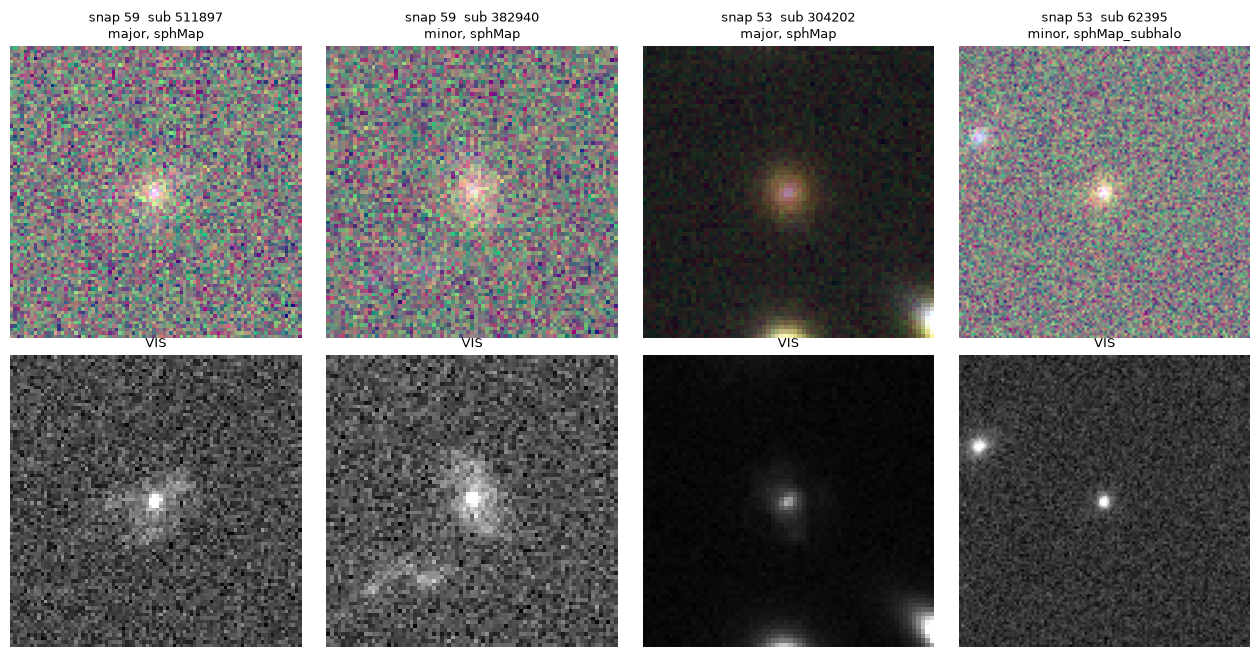

In [8]:
if RUN_TNG_EXAMPLE:
    done = batch[batch.status.isin(["created", "existing"])].reset_index(drop=True)
    fig, axes = plt.subplots(2, len(done), figsize=(3.2 * len(done), 6.6), squeeze=False)
    for i, row in done.iterrows():
        axes[0, i].imshow(rgb_composite(row.hdu_path), origin="lower")
        axes[0, i].set_title(f"snap {row.snapshot}  sub {row.subid}\n{row.merger_type}, {row.render_method}", fontsize=9)
        axes[1, i].imshow(normalised(row.hdu_path, "VIS"), origin="lower", cmap="gray")
        axes[1, i].set_title("VIS", fontsize=9)
    for ax in axes.ravel():
        ax.axis("off")
    fig.tight_layout()

### C2: the same, by hand with `process_sample`

`run_snapshot` is a thin wrapper around a process pool. To parallelise your own galaxy list (any mix of snapshots,
or samples that don't come from the merger catalogue), map `process_sample` over tasks yourself:

- **Use `process_sample`, not `make_mock`, in the pool.** `make_mock` raises on purpose: `RejectedGalaxy`, a render
  timeout when the fallback is off, or network errors. One exception would abort the whole `pool.map`.
  `process_sample` catches them and returns a row with `status` / `error`.
- **A task is `(cfg.toDict(), sample, snapshot)`.** The config travels as a plain dict, because spawned workers on
  macOS must pickle it. The worker rebuilds the DotMap, configures logging and seeds the galaxy's RNG from
  `(seed, snapshot, subid)`, so results don't depend on which worker runs them.
- **A sample needs `subhalo_id`, `merger_type` and the four merger times.** Use `None` where unknown.
- **Here everything runs in one pool across both snapshots**, plus the hand-made sample from Part B. Galaxies already
  produced above come back with status `existing`.
- **Concurrency.** `n_processes` is also the number of simultaneous render requests to the TNG server. Keep it moderate.

In [9]:
from multiprocessing import Pool

from euclid_mocks.merger_catalog import load_or_build_merger_catalog
from euclid_mocks.pipeline import process_sample, select_samples

if RUN_TNG_EXAMPLE:
    tasks = [
        (batch_cfg.toDict(), sample, snap)
        for snap in BATCH_SNAPSHOTS
        for sample in select_samples(batch_cfg, load_or_build_merger_catalog(batch_cfg, snap))
    ]
    # Any sample works, e.g. the hand-made one from Part B.
    tasks.append((batch_cfg.toDict(), tng_sample, snapshot))

    with Pool(processes=batch_cfg.run.n_processes) as pool:
        rows = pool.map(process_sample, tasks)

    manual = pd.DataFrame(rows)
    display(manual[["snapshot", "subid", "merger_type", "status", "render_method", "hdu_path", "error"]])

2026-10-07 13:57:50.004 | INFO     | euclid_mocks.pipeline:make_mock:265 - sub 382940 snap 59: using existing minor_sub-382940_snap-59_view-1,2_BKGPSF_999000001_31.fits
2026-10-07 13:57:50.497 | INFO     | euclid_mocks.pipeline:make_mock:265 - sub 511897 snap 59: using existing major_sub-511897_snap-59_view-1,2_BKGPSF_999000001_33.fits
2026-10-07 13:57:56.018 | INFO     | euclid_mocks.pipeline:make_mock:265 - sub 304202 snap 53: using existing major_sub-304202_snap-53_view-1,2_BKGPSF_999000001_29.fits
2026-10-07 13:57:57.616 | INFO     | euclid_mocks.pipeline:make_mock:265 - sub 62395 snap 53: using existing minor_sub-62395_snap-53_view-1,2_BKGPSF_999000001_1.fits
2026-10-07 13:58:02.581 | INFO     | euclid_mocks.pipeline:make_mock:265 - sub 157 snap 95: using existing example_sub-157_snap-95_view-1,2_BKGPSF_999000001_13.fits


,snapshot,subid,merger_type,status,render_method,hdu_path,error
0,59,511897,major,existing,sphMap,/Users/lruhberg/Documents/Projects/Cosmic-Cudd...,None
1,59,382940,minor,existing,sphMap,/Users/lruhberg/Documents/Projects/Cosmic-Cudd...,None
2,53,304202,major,existing,sphMap,/Users/lruhberg/Documents/Projects/Cosmic-Cudd...,None
3,53,62395,minor,existing,sphMap_subhalo,/Users/lruhberg/Documents/Projects/Cosmic-Cudd...,None
4,95,157,example,existing,sphMap_subhalo,/Users/lruhberg/Documents/Projects/Cosmic-Cudd...,None


## Part D: background positions from a list of MER tiles

The background stage draws positions from `paths.empty_region_dir/TILE_{tile}_empty_regions.csv`. To build these
catalogues for your own tiles, `build_empty_region_catalogs` reads each tile's segmentation map
(`paths.mer_segmap_dir/{tile}/EUC_MER_FINAL-SEGMAP*.fits`), finds round empty patches far from objects and from the
tile border, and writes one CSV per tile. Use `cfg.empty_regions` (the values of the Q1 catalogue) for real 19200² px
tiles. The example below uses the mock tile and its smaller-scale parameters.

> **Ambiguous paths in DR1 deep fields.** In Q1 every tile folder holds exactly one mosaic, PSF grid and segmap
> per band. DR1 deep-field folders can hold **several** images of the same kind (e.g. different stacks or
> processing versions), so a pattern like `EUC_MER_BGSUB-MOSAIC-VIS_TILE{tile}*.fits` can match more than one file.
> The package then uses the alphabetically first match and logs a warning listing all candidates. Check these
> warnings, and make sure the mosaic, PSF grid and segmap you get belong to the same stack. Otherwise, clean the
> folder or point the paths at a curated copy.

In [9]:
from euclid_mocks.empty_regions import build_empty_region_catalogs

TILE_IDS = [cfg.mock_tile.tile_id]  # e.g. [102018211, 102159776] with paths pointing at Q1 MER_SEG / MER
example_dir = Path(cfg.paths.output_dir) / "empty_regions_example"

positions = build_empty_region_catalogs(cfg, TILE_IDS, params=cfg.mock_tile.empty_regions, out_dir=example_dir)
print(f"{len(positions)} background positions in {len(TILE_IDS)} tile(s) -> {example_dir}")
print("use them with: cfg.paths.empty_region_dir =", str(example_dir))
positions.head()

2026-10-07 11:54:40.641 | INFO     | euclid_mocks.empty_regions:find_empty_regions:105 - tile 999000001: 52 empty regions from 63 seeds


52 background positions in 1 tile(s) -> /Users/lruhberg/Documents/Projects/CosmicCuddles/StandaloneMockImaging/output/empty_regions_example
use them with: cfg.paths.empty_region_dir = /Users/lruhberg/Documents/Projects/CosmicCuddles/StandaloneMockImaging/output/empty_regions_example


,Folder_name,pos_x,pos_y,pos_ra,pos_dec,min_object_distance,border_distance
0,999000001,684.000000,130.000000,269.988224,65.989402,31,130
1,999000001,739.000000,109.000000,269.984470,65.988819,73,109
2,999000001,820.000000,119.000000,269.978940,65.989096,20,119
3,999000001,917.000000,100.000000,269.972319,65.988567,91,100
4,999000001,220.785268,124.706617,270.019846,65.989254,45,124


## Batch mode from the command line

`python scripts/run_mock_imaging.py` runs Part C for every snapshot in `cfg.run.snapshots` with the configured
sample sizes (`--snapshots 59 53` for a subset).